# HRN Current-Run Trade-Off Plots

This notebook mirrors the Hier-COS current-run plots with a smaller run matrix: the native HRN baseline, coarse-first explicit lexicographic training, and HCC with `step@0` or `step@160`. The delayed epoch is 80% of HRN's 200-epoch schedule, matching the relative timing of H-CAST `step@80`. It reads the independently selected test checkpoint for every completed seed.

HCC activation is verified from logged `proj_constraint_alpha`, not inferred from directory names. The summary reports both the first active logged epoch and the HCC alpha stored in the independently selected checkpoint's test metrics.

FPA and level accuracy are higher-is-better; TICE is lower-is-better. Points and error bars are mean ± sample standard deviation across training seeds. The native HRN baseline uses the paper-aligned native objective, whereas lex and HCC require `model.loss=level_marginal`; their deltas therefore combine an objective change with the lexicographic/HCC mechanism and are not single-variable causal estimates.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

for root in (Path.cwd(), *Path.cwd().parents):
    helper_dir = root / 'analysis' / 'current_runs'
    if (helper_dir / 'current_run_plot_utils.py').is_file():
        sys.path.insert(0, str(helper_dir))
        break
else:
    raise FileNotFoundError('Run this notebook from the repository tree so analysis/current_runs is discoverable.')

from current_run_plot_utils import (
    discover_reference_rows, discover_rows, model_reference_specs,
    plot_fpa_tice, plot_level_accuracy_deltas, print_availability,
    print_reference_availability, print_summary,
)

plt.style.use('seaborn-v0_8-whitegrid')
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
SAVE_FIGURES = False
FIGURE_DIR = OUTPUTS_ROOT / 'analysis' / 'current_runs' / 'hrn'

DATASETS = {
    'cifar100': 'CIFAR-100',
    'cub200': 'CUB-200',
    'aircraft': 'Aircraft',
}

RUN_SPECS = [
    {'key': 'baseline', 'label': 'Baseline', 'family': 'baseline', 'color': '#0072B2', 'marker': 'o', 'hatch': '',
     'run_name': 'hrn_{dataset}'},
    {'key': 'lex_coarse_first', 'label': 'Lex coarse-first', 'family': 'lex', 'color': '#D55E00', 'marker': '^', 'hatch': '//',
     'run_name': 'hrn_{dataset}_level_marginal_lex_orthogonalize_all_coarse_first'},
    {'key': 'hcc_step_0', 'label': 'HCC step@0', 'family': 'hcc', 'color': '#009E73', 'marker': 's', 'hatch': '\\',
     'run_name': 'hrn_hcc_{dataset}_level_marginal_step_0epoch'},
    {'key': 'hcc_step_160', 'label': 'HCC step@160', 'family': 'hcc', 'color': '#CC79A7', 'marker': 'D', 'hatch': 'xx',
     'run_name': 'hrn_hcc_{dataset}_level_marginal_step_160epoch'},
]

REFERENCE_SPECS = model_reference_specs(exclude={'hrn'})


In [2]:
rows, missing_runs = discover_rows(OUTPUTS_ROOT, DATASETS, RUN_SPECS)
reference_rows, missing_reference_runs = discover_reference_rows(OUTPUTS_ROOT, DATASETS, REFERENCE_SPECS)
print_availability(rows, missing_runs, DATASETS)
print_reference_availability(reference_rows, missing_reference_runs, DATASETS)


CIFAR-100
  Baseline                 missing: hrn_cifar100
  Lex coarse-first         missing: hrn_cifar100_level_marginal_lex_orthogonalize_all_coarse_first
  HCC step@0               missing: hrn_hcc_cifar100_level_marginal_step_0epoch
  HCC step@160             missing: hrn_hcc_cifar100_level_marginal_step_160epoch

CUB-200
  Baseline                  3 seed(s): hrn_cub200
  Lex coarse-first         missing: hrn_cub200_level_marginal_lex_orthogonalize_all_coarse_first
  HCC step@0               missing: hrn_hcc_cub200_level_marginal_step_0epoch
  HCC step@160             missing: hrn_hcc_cub200_level_marginal_step_160epoch

Aircraft
  Baseline                  3 seed(s): hrn_aircraft
  Lex coarse-first         missing: hrn_aircraft_level_marginal_lex_orthogonalize_all_coarse_first
  HCC step@0               missing: hrn_hcc_aircraft_level_marginal_step_0epoch
  HCC step@160             missing: hrn_hcc_aircraft_level_marginal_step_160epoch

CIFAR-100 reference models
  H-CAST      

## Independent FPA–TICE Trade-Off

Each panel shows individual seeds, the across-seed mean, a one-standard-deviation covariance ellipse when at least three seeds are available, and collision-aware direct labels. Higher FPA and lower TICE are preferred.

Other model baselines use the same off-scale representation as the Hier-COS notebook. The axis range is frozen on HRN runs alone. A contextual model outside that range is pinned into a shaded gutter; its triangle tip points toward the true value, while the label reports the actual FPA and TICE. A square marks an in-range reference. These models are context rather than controlled comparisons and are excluded from HRN Pareto analysis.

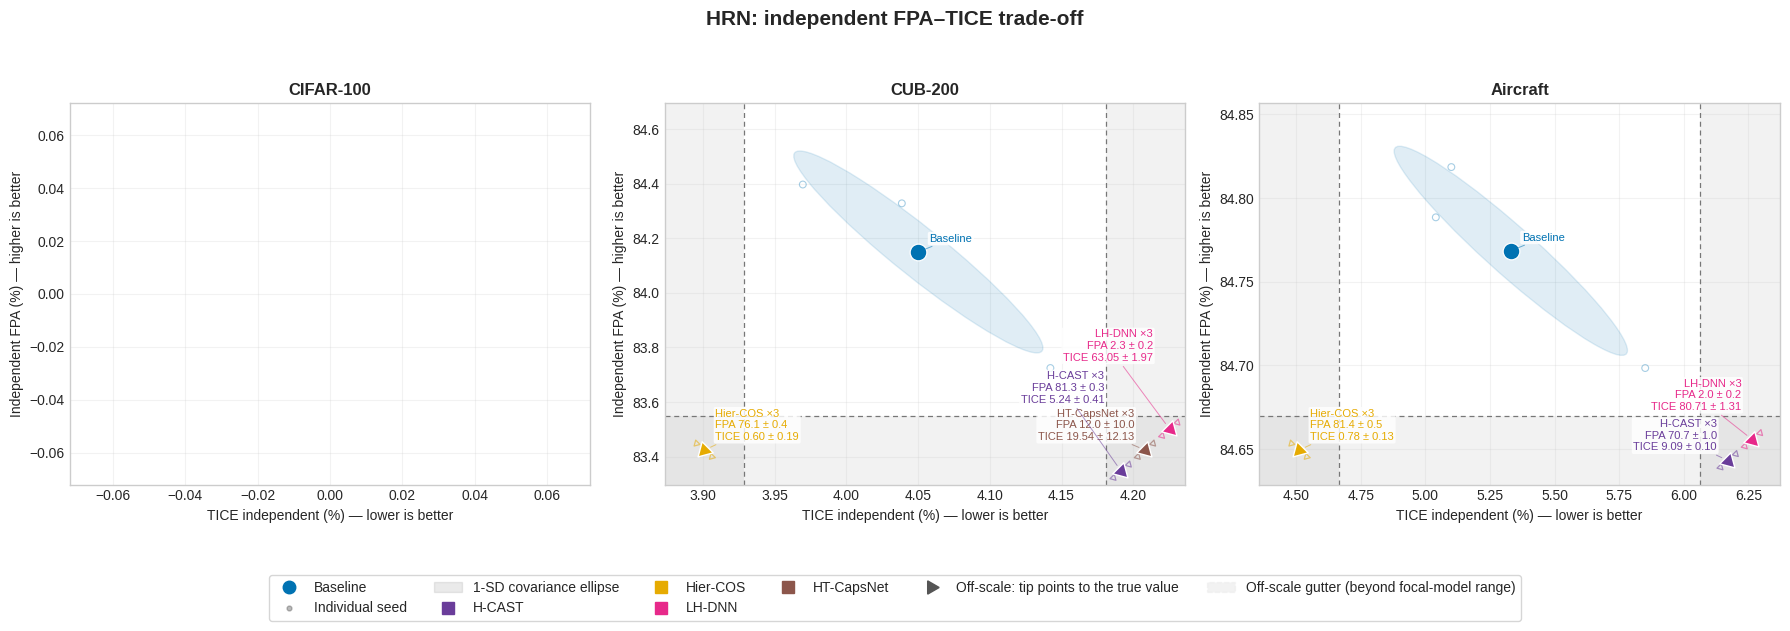

In [3]:
plot_fpa_tice(
    rows, DATASETS, 'HRN', FIGURE_DIR, SAVE_FIGURES,
    reference_rows=reference_rows, reference_specs=REFERENCE_SPECS,
)

## Selected-Run Effects Across Hierarchy Levels

Bars are matched-seed changes in independent coarse, middle, and fine accuracy from the native HRN baseline. Values are percentage-point deltas. Missing runs and seed pairs are omitted. Because lex and HCC use the `level_marginal` objective while the native baseline does not, the bars are descriptive comparisons rather than isolated mechanism effects.

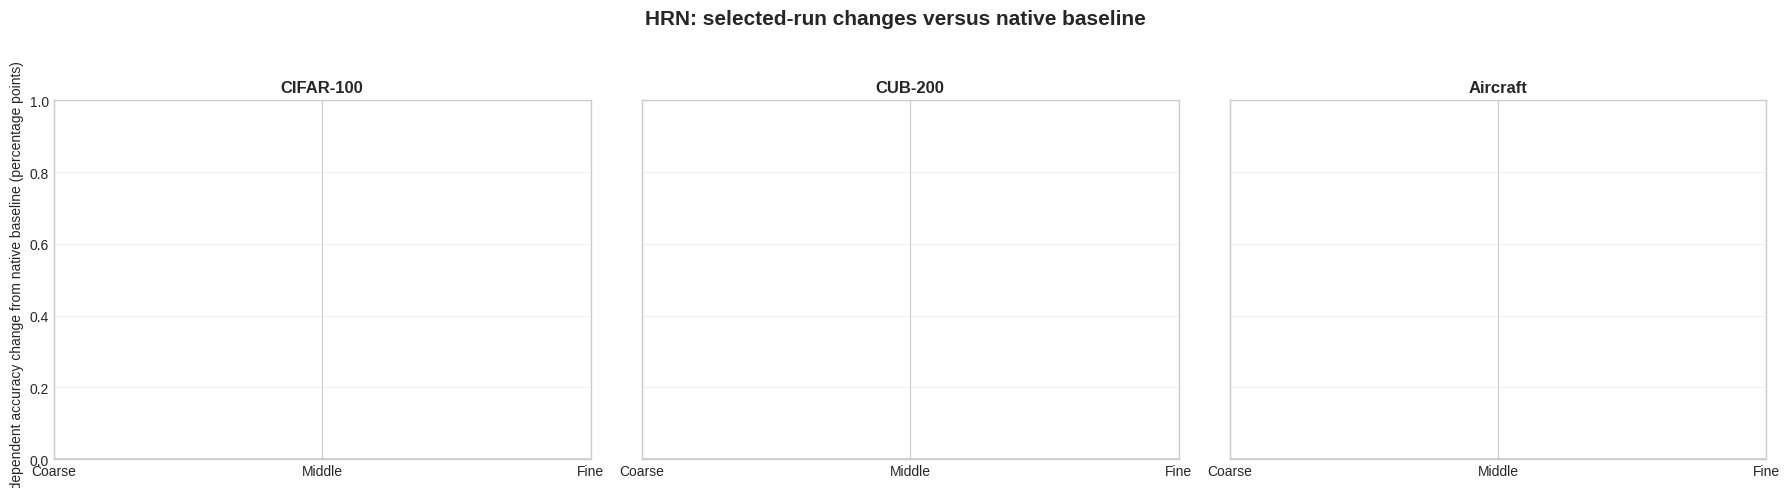

In [4]:
plot_level_accuracy_deltas(rows, DATASETS, 'HRN', FIGURE_DIR, SAVE_FIGURES)

## Run and Pareto Summary

A run is Pareto-optimal within a dataset when no available HRN run has both higher-or-equal FPA and lower-or-equal TICE, with at least one strict improvement. HCC diagnostics make activation and checkpoint timing explicit.

In [5]:
print_summary(rows, DATASETS)


CIFAR-100
  run                      n   epoch             FPA               TICE              HCC diagnostics          status

CUB-200
  run                      n   epoch             FPA               TICE              HCC diagnostics          status
  Baseline                  3  168.0 ± 25.5      84.15% ± 0.37     4.05% ± 0.09      —                        Pareto-optimal

Aircraft
  run                      n   epoch             FPA               TICE              HCC diagnostics          status
  Baseline                  3  190.3 ± 10.6      84.77% ± 0.06     5.33% ± 0.45      —                        Pareto-optimal
